In [6]:
import pandas as pd


In [7]:
df = pd.read_csv("healthcare_dataset.csv")
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [8]:
print("data types:\n" , df.dtypes)

data types:
 Name                   object
Age                     int64
Gender                 object
Blood Type             object
Medical Condition      object
Date of Admission      object
Doctor                 object
Hospital               object
Insurance Provider     object
Billing Amount        float64
Room Number             int64
Admission Type         object
Discharge Date         object
Medication             object
Test Results           object
dtype: object


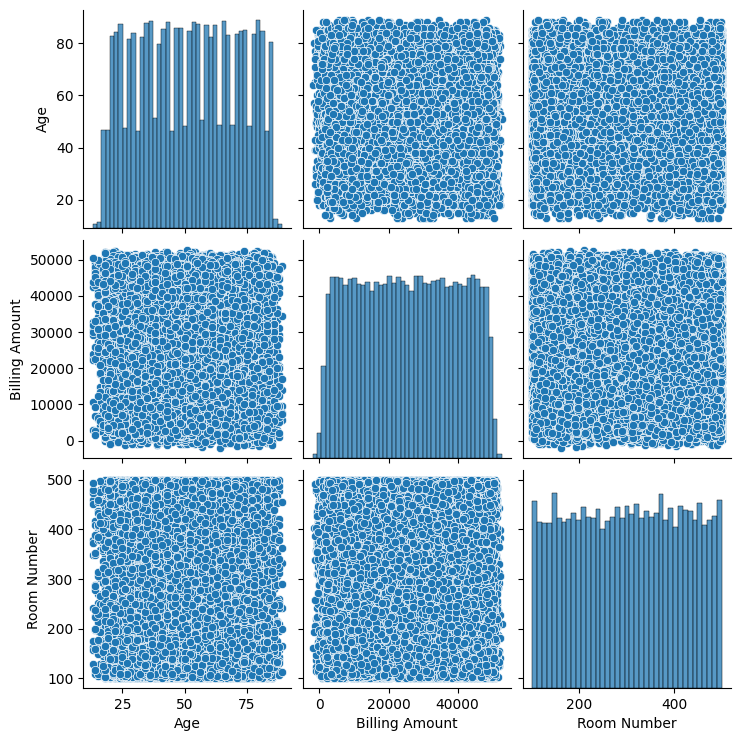

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(df)
plt.show()

In [10]:
print(f'number of records :{df.shape[0]} ')
print(f'number of features :{df.shape[1]} ')

number of records :55500 
number of features :15 


In [11]:
print(df.isnull().sum())

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


In [12]:
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
categorical_cols = ['Age', 'Gender', 'Blood Type', 'Medical Condition', 'Hospital', 'Insurance Provider', 'Admission Type', 'Medication', 'Test Results']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [13]:
drop_columns = ['Room Number', 'Discharge Date', 'Date of Admission','Hospital' ,'Doctor' , 'Name', 'Test Results']
X = df.drop(drop_columns, axis=1)
y = df['Test Results']
X.head()

,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Billing Amount,Admission Type,Medication
0,17,1,5,2,1,18856.281306,2,3
1,49,1,0,5,3,33643.327287,1,1
2,63,0,1,5,0,27955.096079,1,0
3,15,0,6,3,3,37909.782410,0,1
4,30,0,2,2,0,14238.317814,2,4


In [14]:
from sklearn.model_selection import train_test_split


X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [15]:
print(X_train.dtypes)


Age                     int64
Gender                  int64
Blood Type              int64
Medical Condition       int64
Insurance Provider      int64
Billing Amount        float64
Admission Type          int64
Medication              int64
dtype: object


In [16]:
X_train.shape

(33300, 8)

In [17]:
y_train.shape


(33300,)

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
model = Sequential()
model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(3, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3357 - loss: 111.9008 - val_accuracy: 0.3382 - val_loss: 34.9171
Epoch 2/10
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3362 - loss: 68.4583 - val_accuracy: 0.3303 - val_loss: 12.1903
Epoch 3/10
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.3341 - loss: 50.1662 - val_accuracy: 0.3299 - val_loss: 60.6655
Epoch 4/10
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3238 - loss: 34.8742 - val_accuracy: 0.3297 - val_loss: 42.1256
Epoch 5/10
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.3261 - loss: 24.5585 - val_accuracy: 0.3305 - val_loss: 12.9159
Epoch 6/10
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3306 - loss: 21.4716 - val_accuracy: 0.3311 - val_loss: 9.5847
Epoch 7/10
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3356 - loss: 17.3637 - val_accuracy: 0.3402 - val_loss: 9.6677
Epoch 8/10
1041/1041 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3333 - lo

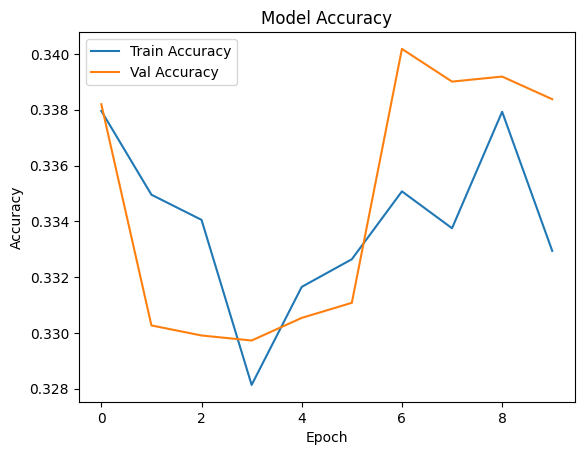

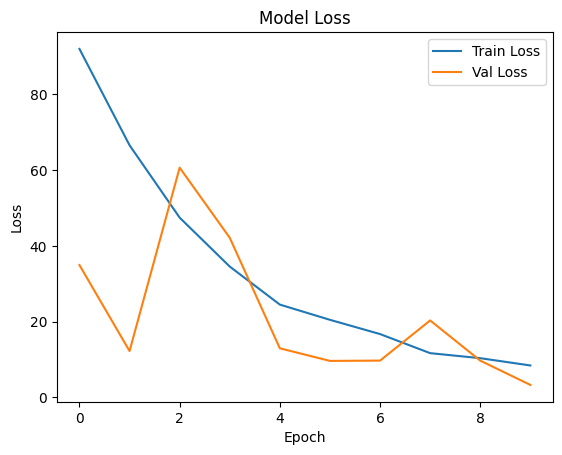

In [19]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [20]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

l2_values = [0.0, 0.001, 0.01, 0.1]
loss_per_lambda = {}
histories = {}

for l2_lambda in l2_values:
    print(f"\nTraining with L2 regularization = {l2_lambda}")

    model = Sequential()
    model.add(Dense(128, input_dim=X_train.shape[1], activation='relu', kernel_regularizer=l2(l2_lambda)))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(l2_lambda)))
    model.add(Dense(3, activation='softmax'))  # 3 classes in 'Test Results'

    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    history = model.fit(X_train, y_train, epochs=10, batch_size=32,
                        validation_data=(X_val, y_val), verbose=0)

    histories[l2_lambda] = history
    final_loss = history.history['val_loss'][-1]
    loss_per_lambda[l2_lambda] = final_loss



Training with L2 regularization = 0.0


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with L2 regularization = 0.001


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with L2 regularization = 0.01


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with L2 regularization = 0.1


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


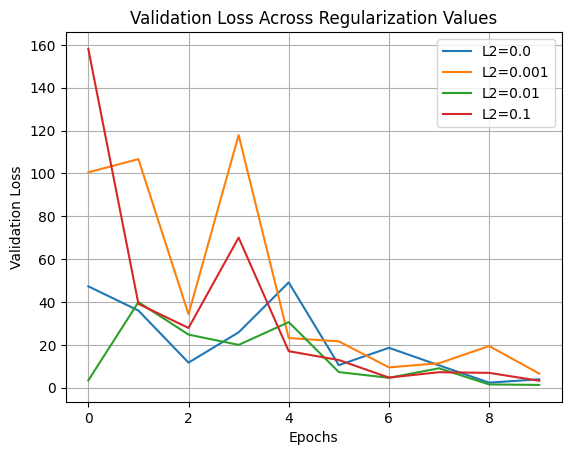

In [21]:
for l2_lambda, history in histories.items():
    plt.plot(history.history['val_loss'], label=f'L2={l2_lambda}')

plt.title("Validation Loss Across Regularization Values")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


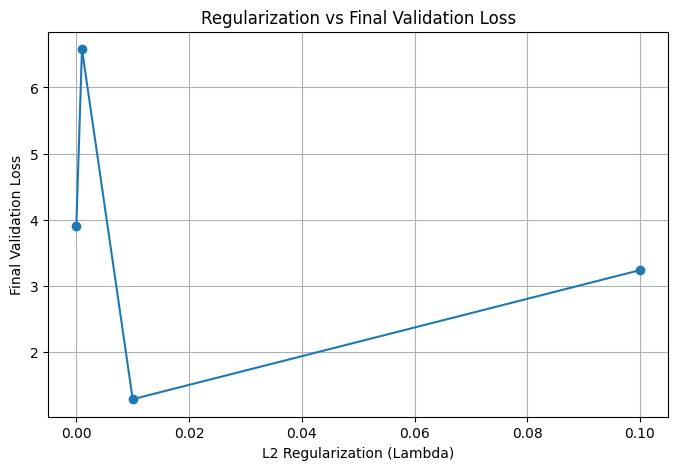

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(list(loss_per_lambda.keys()), list(loss_per_lambda.values()), marker='o')
plt.title("Regularization vs Final Validation Loss")
plt.xlabel("L2 Regularization (Lambda)")
plt.ylabel("Final Validation Loss")
plt.grid(True)
plt.show()
